# Deep RNN

In [7]:
import matplotlib.pyplot as plt

import tensorflow as tf 
from tensorflow import keras
from keras.layers import Embedding, SimpleRNN, Dense, LSTM, GRU, Input
from keras.models import Sequential
from keras.preprocessing.sequence import pad_sequences

from keras.datasets import imdb

In [2]:
(x_train, y_train),(x_test, y_test) = imdb.load_data(num_words=10000)

x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

In [3]:
model = Sequential()

model.add(Input(shape=(100, )))
model.add(Embedding(input_dim=10000, output_dim=32, input_length=100))

model.add(SimpleRNN(5, return_sequences=True))
model.add(SimpleRNN(5))

model.add(Dense(1, activation='sigmoid'))

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┓
┃                ┃ Output    ┃ Param ┃
┃ Layer (type)   ┃ Shape     ┃     # ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━┩
│ embedding      │ (None,    │ 320,… │
│ (Embedding)    │ 100, 32)  │       │
├────────────────┼───────────┼───────┤
│ simple_rnn     │ (None,    │   190 │
│ (SimpleRNN)    │ 100, 5)   │       │
├────────────────┼───────────┼───────┤
│ simple_rnn_1   │ (None, 5) │    55 │
│ (SimpleRNN)    │           │       │
├────────────────┼───────────┼───────┤
│ dense (Dense)  │ (None, 1) │     6 │
└────────────────┴───────────┴───────┘

 Total params: 320,251 (1.22 MB)

 Trainable params: 320,251 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

In [6]:
history = model.fit(x_train, y_train, epochs=25, validation_data=(x_test, y_test))

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.7572 - loss: 0.5109 - val_accuracy: 0.7909 - val_loss: 0.4758
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.8418 - loss: 0.3845 - val_accuracy: 0.8110 - val_loss: 0.4292
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.8848 - loss: 0.3003 - val_accuracy: 0.8130 - val_loss: 0.4379
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9168 - loss: 0.2307 - val_accuracy: 0.8134 - val_loss: 0.4714
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9363 - loss: 0.1807 - val_accuracy: 0.8038 - val_loss: 0.5058
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9524 - loss: 0.1437 - val_accuracy: 0.8006 - val_loss: 0.5532
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9600 - loss: 0.1227 - val_accuracy: 0.7953 - val_loss: 0.6283
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9681 - loss: 0.1032 - 

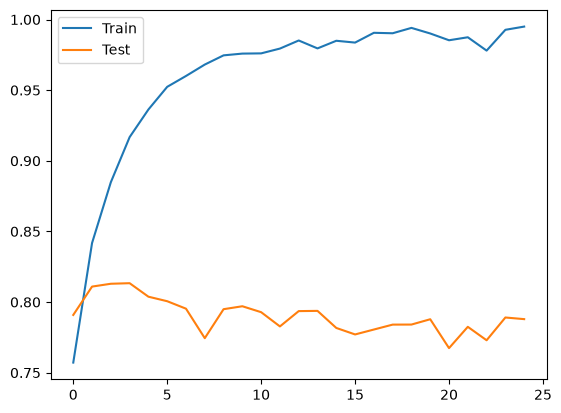

In [8]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.legend()
plt.show()

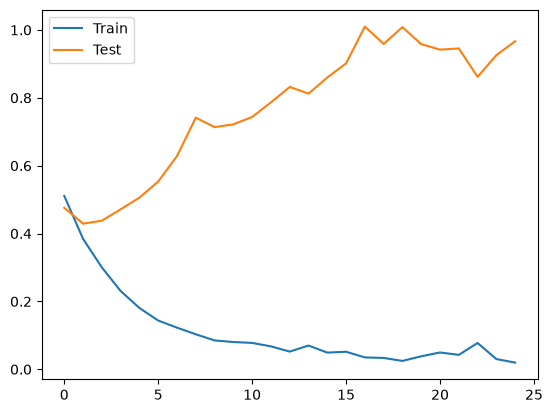

In [10]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.legend()
plt.show()

# Deep LSTM

In [12]:
model_lstm = Sequential()

model_lstm.add(Input(shape=(100, )))
model_lstm.add(Embedding(input_dim=10000, output_dim=32))

model_lstm.add(LSTM(5,return_sequences=True))
model_lstm.add(LSTM(5))

model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┓
┃                ┃ Output    ┃ Param ┃
┃ Layer (type)   ┃ Shape     ┃     # ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━┩
│ embedding_3    │ (None,    │ 320,… │
│ (Embedding)    │ 100, 32)  │       │
├────────────────┼───────────┼───────┤
│ lstm_2 (LSTM)  │ (None,    │   760 │
│                │ 100, 5)   │       │
├────────────────┼───────────┼───────┤
│ lstm_3 (LSTM)  │ (None, 5) │   220 │
├────────────────┼───────────┼───────┤
│ dense_1        │ (None, 1) │     6 │
│ (Dense)        │           │       │
└────────────────┴───────────┴───────┘

 Total params: 320,986 (1.22 MB)

 Trainable params: 320,986 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_lstm.compile(metrics=['accuracy'], loss='binary_crossentropy', optimizer='adam')

In [16]:
history_lstm = model_lstm.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - accuracy: 0.7594 - loss: 0.4974 - val_accuracy: 0.8214 - val_loss: 0.4113
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.8790 - loss: 0.3069 - val_accuracy: 0.8460 - val_loss: 0.3676
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9142 - loss: 0.2320 - val_accuracy: 0.8396 - val_loss: 0.4009
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9346 - loss: 0.1829 - val_accuracy: 0.8422 - val_loss: 0.4126
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.9520 - loss: 0.1408 - val_accuracy: 0.8327 - val_loss: 0.4483
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9664 - loss: 0.1086 - val_accuracy: 0.8304 - val_loss: 0.4663
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9741 - loss: 0.0888 - val_accuracy: 0.8293 - val_loss: 0.5812
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9790 - loss: 0.0760 - 

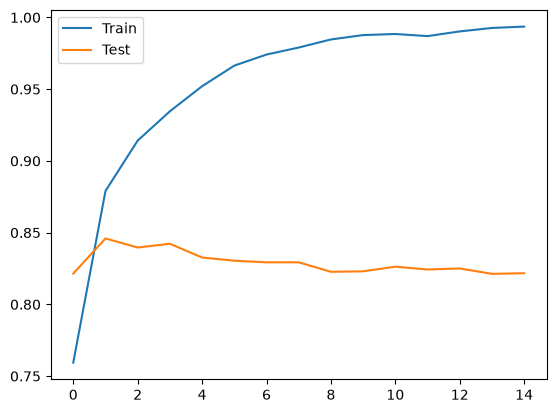

In [17]:
plt.plot(history_lstm.history['accuracy'], label='Train')
plt.plot(history_lstm.history['val_accuracy'], label='Test')
plt.legend()
plt.show()

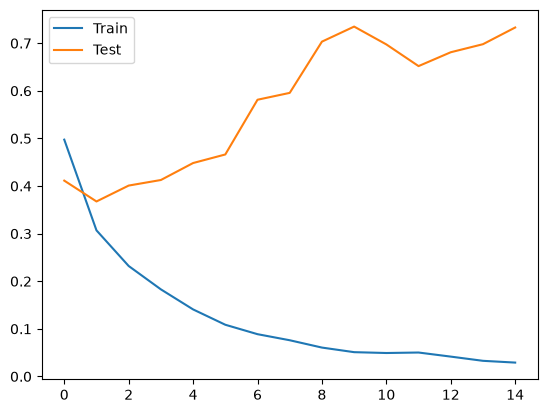

In [18]:
plt.plot(history_lstm.history['loss'], label='Train')
plt.plot(history_lstm.history['val_loss'], label='Test')
plt.legend()
plt.show()

# Deep GRU

In [21]:
model_gru = Sequential()

model_gru.add(Input(shape=(100, )))
model_gru.add(Embedding(input_dim = 10000, output_dim=32, input_length=100))

model_gru.add(GRU(5,return_sequences=True))
model_gru.add(GRU(5))

model_gru.add(Dense(1, activation='sigmoid'))

model_gru.summary()

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┓
┃                ┃ Output    ┃ Param ┃
┃ Layer (type)   ┃ Shape     ┃     # ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━┩
│ embedding_5    │ (None,    │ 320,… │
│ (Embedding)    │ 100, 32)  │       │
├────────────────┼───────────┼───────┤
│ gru_1 (GRU)    │ (None,    │   585 │
│                │ 100, 5)   │       │
├────────────────┼───────────┼───────┤
│ gru_2 (GRU)    │ (None, 5) │   180 │
├────────────────┼───────────┼───────┤
│ dense_2        │ (None, 1) │     6 │
│ (Dense)        │           │       │
└────────────────┴───────────┴───────┘

 Total params: 320,771 (1.22 MB)

 Trainable params: 320,771 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_gru.compile(metrics=['accuracy'], loss='binary_crossentropy', optimizer='adam')
history_gru = model_gru.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.7522 - loss: 0.5048 - val_accuracy: 0.8209 - val_loss: 0.4109
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.8660 - loss: 0.3296 - val_accuracy: 0.8328 - val_loss: 0.3872
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9014 - loss: 0.2588 - val_accuracy: 0.8440 - val_loss: 0.3638
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9240 - loss: 0.2091 - val_accuracy: 0.8393 - val_loss: 0.3878
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9418 - loss: 0.1648 - val_accuracy: 0.8357 - val_loss: 0.4245
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9597 - loss: 0.1227 - val_accuracy: 0.8326 - val_loss: 0.4841
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9730 - loss: 0.0916 - val_accuracy: 0.8236 - val_loss: 0.5746
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9788 - loss: 0.0700 - 

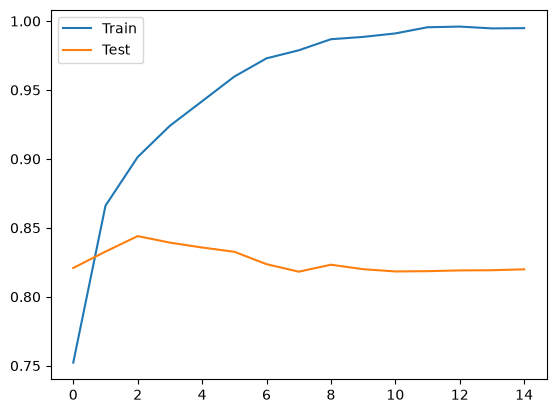

In [23]:
plt.plot(history_gru.history['accuracy'], label='Train')
plt.plot(history_gru.history['val_accuracy'], label='Test')
plt.legend()
plt.show()

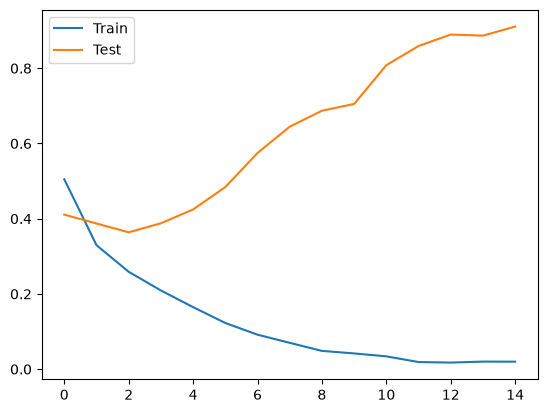

In [24]:
plt.plot(history_gru.history['loss'], label='Train')
plt.plot(history_gru.history['val_loss'], label='Test')
plt.legend()
plt.show()